<a href="https://colab.research.google.com/github/EduardoZamora03/Proyecto-samsung/blob/main/Limpieza_de_datos_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('RT_IOT2022_formateado.csv')
display(df.head())

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 non-null  f

In [ ]:
df.shape

(123117, 85)

In [ ]:
display(df.isnull().sum().sort_values(ascending=False))

,0
Unnamed: 0,0
id.orig_p,0
id.resp_p,0
proto,0
service,0
...,...
idle.std,0
fwd_init_window_size,0
bwd_init_window_size,0
fwd_last_window_size,0


In [ ]:
#Cantidad de ataques
label = 'Attack_type'
if 'Attack_type' in df.columns:
    print("\nLabel Distribution:")
    display(df['Attack_type'].value_counts())

else:
    print("\n No 'label' column found")


Label Distribution:


,count
Attack_type,
DOS_SYN_Hping,94659
Thing_Speak,8108
ARP_poisioning,7750
MQTT_Publish,4146
NMAP_UDP_SCAN,2590
NMAP_XMAS_TREE_SCAN,2010
NMAP_OS_DETECTION,2000
NMAP_TCP_scan,1002
DDOS_Slowloris,534


Limpieza de datos

In [ ]:
data = df.copy() #Creamos una copia del dataset original

In [ ]:
#Se elimina datos repetidos
data = data.drop_duplicates()

In [ ]:
#Se elimina la columna Unnamed: 0
if 'Unnamed: 0' in df.columns:
  data = data.drop(columns=['Unnamed: 0'])

In [ ]:
#Se elimina valores infinitos
numeric_cols = data.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
  if np.isinf(data[col]).any():
    max_val = data.loc[np.isfinite(data[col])].max()
    data[col] = data[col].replace([np.inf, -np.inf], max_val)

In [ ]:
#Limpieza de datos NaN
for col in data.columns:
    if data[col].isnull().any():
        if data[col].dtype == 'object':
            data[col] = data[col].fillna('unknown')
        else:
            data[col] = data[col].fillna(0)

In [ ]:
#Eliminamos las columnas id.orig_p, id.resp_p
columnas_a_eliminar = ['id.orig_p', 'id.resp_p']
data = data.drop(columns=[col for col in columnas_a_eliminar if col in data.columns])

In [ ]:
#Conversion de datos TCP y UDP, los dividimos en varias columnas (1 = si; 0 = no)
columnas_categoricas = ['proto', 'service']
columnas_a_codificar = [col for col in columnas_categoricas if col in data.columns]
data = pd.get_dummies(data, columns=columnas_a_codificar, dtype = int)

#Revision de si hay infinitos despues del encoding
print("Infinitos después de encoding:", np.isinf(data.select_dtypes(include=[np.number])).sum().sum())
data

Infinitos después de encoding: 0


,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,...,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl
0,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
1,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
2,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
3,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
4,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,0.000006,1,1,0,0,167772.160000,167772.160000,335544.320000,1.000000,20,...,1,0,0,0,0,0,0,0,0,0
123113,0.000007,1,1,0,0,144631.172414,144631.172414,289262.344828,1.000000,20,...,1,0,0,0,0,0,0,0,0,0
123114,0.000006,1,1,0,0,167772.160000,167772.160000,335544.320000,1.000000,20,...,1,0,0,0,0,0,0,0,0,0
123115,0.000006,1,1,0,0,167772.160000,167772.160000,335544.320000,1.000000,20,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
#Seleccion de caracteristicas
if 'Attack_type' in data.columns:
  dataset_numerico = data.drop(columns=['Attack_type'])
else:
  dataset_numerico = data.copy()

#Matriz de correlacion
correlacion = dataset_numerico.corr().abs()
upper = correlacion.where(np.triu(np.ones(correlacion.shape), k=1).astype(bool))

#Se eliminan columnas con una correlacion mayor a 0.99
columnas_a_eliminar = [columna for columna in upper.columns if any(upper[columna] > 0.99)] #Se elimina la columna del protocolo udp, como son solo dos protocolos udp y tcp, si es 1=tcp, 0=udp
data_correlacion = data.drop(columns=columnas_a_eliminar)
data_correlacion = data_correlacion.reset_index(drop=True)
print(f"Columnas eliminadas: {columnas_a_eliminar}") #Proto_icmp = paquete de datos enviado como un pingeo
print(f"Anterior tamaño: {data.shape}")
print(f"Nuevo tamaño: {data_correlacion.shape}")
data_correlacion

Columnas eliminadas: ['bwd_data_pkts_tot', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'bwd_pkts_payload.tot', 'flow_pkts_payload.tot', 'fwd_iat.tot', 'flow_iat.max', 'flow_iat.tot', 'bwd_bulk_packets', 'idle.max', 'idle.tot', 'idle.avg', 'proto_udp']
Anterior tamaño: (123117, 93)
Nuevo tamaño: (123117, 80)


,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,fwd_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,...,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl
0,32.011598,9,5,3,0.281148,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
1,31.883584,9,5,3,0.282277,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
2,32.124053,9,5,3,0.280164,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
3,31.961063,9,5,3,0.281593,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
4,31.902362,9,5,3,0.282111,0.555556,296,32,40,168,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,0.000006,1,1,0,167772.160000,1.000000,20,20,20,20,...,1,0,0,0,0,0,0,0,0,0
123113,0.000007,1,1,0,144631.172414,1.000000,20,20,20,20,...,1,0,0,0,0,0,0,0,0,0
123114,0.000006,1,1,0,167772.160000,1.000000,20,20,20,20,...,1,0,0,0,0,0,0,0,0,0
123115,0.000006,1,1,0,167772.160000,1.000000,20,20,20,20,...,1,0,0,0,0,0,0,0,0,0


Matriz de correlacion

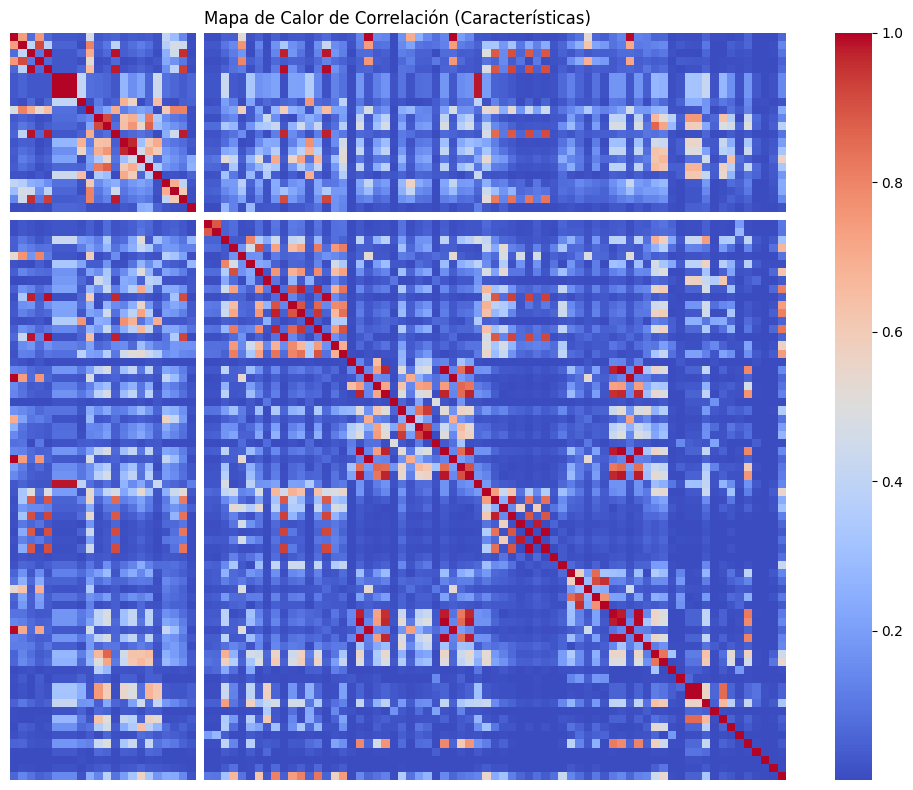

In [ ]:
#Mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title('Mapa de Calor de Correlación (Características)')
plt.tight_layout()
plt.show()

Dataset para clustering

In [ ]:
Target_regresion = 'flow_duration'

if Target_regresion in data_correlacion.columns:
  target = data_correlacion[Target_regresion]
  dataset_features = data_correlacion.drop(columns=[Target_regresion, 'Attack_type'], errors = 'ignore') #Eliminamos attack type ya que es una columna de tipo caracteres y la variable objetivo de la regresion
else:
  raise ValueError(f"La columna '{Target_regresion}' no se encuentra en el DataFrame.")

#Se inicia el escalador
scaler = StandardScaler()
columnas  = dataset_features.columns
datos_escalados = scaler.fit_transform(dataset_features)
data_escalado = pd.DataFrame(datos_escalados, columns=columnas)

#Aqui se almacena para clustering, sin la variable objetivo
data_escalado.to_csv('RT_IOT2022_clustering.csv', index=False) #Datos limpios, estandarizados y sin la variable objetivo
data_escalado

,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,fwd_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,...,service_-,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl
0,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-2.253453,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688
1,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-2.253453,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688
2,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-2.253453,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688
3,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-2.253453,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688
4,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-2.253453,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,-0.056805,-0.027546,-0.074928,-0.496366,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,0.443763,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688
123113,-0.056805,-0.027546,-0.074928,-0.558781,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,0.443763,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688
123114,-0.056805,-0.027546,-0.074928,-0.496366,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,0.443763,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688
123115,-0.056805,-0.027546,-0.074928,-0.496366,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,0.443763,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688


Dataset para regresion

In [ ]:
data_escalado[Target_regresion] = target.values

data_escalado.to_csv('RT_IOT2022_regresion.csv', index=False) #Datos limpios, estandarizados, sin balanceo
data_escalado

,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,fwd_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,...,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl,flow_duration
0,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,32.011598
1,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,31.883584
2,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,32.124053
3,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,31.961063
4,0.301353,0.093600,0.077860,-0.948870,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,31.902362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,-0.056805,-0.027546,-0.074928,-0.496366,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,0.000006
123113,-0.056805,-0.027546,-0.074928,-0.558781,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,0.000007
123114,-0.056805,-0.027546,-0.074928,-0.496366,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,0.000006
123115,-0.056805,-0.027546,-0.074928,-0.496366,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,0.000006


Dataset clasificacion

In [ ]:
#X = Caracteristicas; Y = Etiquetas
# Usamos dataset_escalado sin el target de regresion, y agregamos Attack_type para clasificacion
X = data_escalado.drop(columns=[Target_regresion], errors='ignore')
y = data_correlacion['Attack_type'].values  # Tomamos Attack_type del dataset original

# Creamos el dataset final solo con datos REALES
data_limpio = pd.DataFrame(X, columns=X.columns)
data_limpio['Attack_type'] = y

In [ ]:
#NUEVO: Eliminar clases con muestras insuficientes
UMBRAL_MINIMO = 20

conteo_clases = data_limpio['Attack_type'].value_counts()
clases_validas = conteo_clases[conteo_clases >= UMBRAL_MINIMO].index
clases_eliminadas = set(conteo_clases.index) - set(clases_validas) #Se llega a eliminar la clase NMPA_FIN_SCAN ya que la cantidad de datos es muy poca lo cual genera problemas para su entrenamiento

if clases_eliminadas:
    print(f"\nClases eliminadas por muestras insuficientes (<{UMBRAL_MINIMO}): {clases_eliminadas}")
    dataset_limpio = data_limpio[data_limpio['Attack_type'].isin(clases_validas)].copy()
else:
    print(f"\nTodas las clases superan el umbral mínimo de {UMBRAL_MINIMO} muestras.")


Todas las clases superan el umbral mínimo de 20 muestras.


In [ ]:
print("\nDistribución de datos REALES listos para guardar:")
print(data_limpio['Attack_type'].value_counts())
print(f"\nClases finales: {data_limpio['Attack_type'].nunique()}")
print(f"Muestras totales: {len(data_limpio)}")



# Mezclado de los datos reales
data_limpio = data_limpio.sample(frac=1, random_state=42).reset_index(drop=True)

data_limpio.to_csv('RT_IOT2022_clasificacion.csv', index=False)
data_limpio


Distribución de datos REALES listos para guardar:
Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64

Clases finales: 12
Muestras totales: 123117


,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,fwd_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,...,service_dhcp,service_dns,service_http,service_irc,service_mqtt,service_ntp,service_radius,service_ssh,service_ssl,Attack_type
0,-0.056805,-0.027546,-0.023999,1.313655,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,DOS_SYN_Hping
1,-0.056805,-0.027546,-0.023999,-0.241832,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,DOS_SYN_Hping
2,-0.056805,-0.027546,-0.023999,0.308088,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,DOS_SYN_Hping
3,0.301353,0.093600,0.077860,-0.948871,-0.885605,0.616010,2.285145,2.676563,0.118041,1.788560,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,MQTT_Publish
4,-0.056805,-0.057832,-0.023999,-0.948871,-2.531019,-0.086235,0.041251,-0.089430,-0.045347,-2.212669,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,DOS_SYN_Hping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,-0.056805,-0.057832,-0.074928,-0.948871,-2.531019,-0.116767,-2.202643,-1.749025,-0.045347,-2.212669,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,NMAP_UDP_SCAN
123113,-0.056805,-0.027546,-0.023999,1.313655,0.430725,-0.086235,0.041251,-0.089430,-0.025896,0.288099,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,-0.148688,DOS_SYN_Hping
123114,0.346123,0.123886,0.077860,-0.948871,-0.753973,0.697429,2.285145,2.676563,0.149163,1.788560,...,-0.020156,-0.293313,-0.170148,-0.018692,5.366189,-0.031365,-0.004031,-0.015082,-0.148688,MQTT_Publish
123115,0.480433,0.214745,0.128789,-0.948869,-0.480580,0.941688,2.285145,2.676563,0.242528,1.788560,...,-0.020156,-0.293313,-0.170148,-0.018692,-0.186352,-0.031365,-0.004031,-0.015082,6.725507,ARP_poisioning


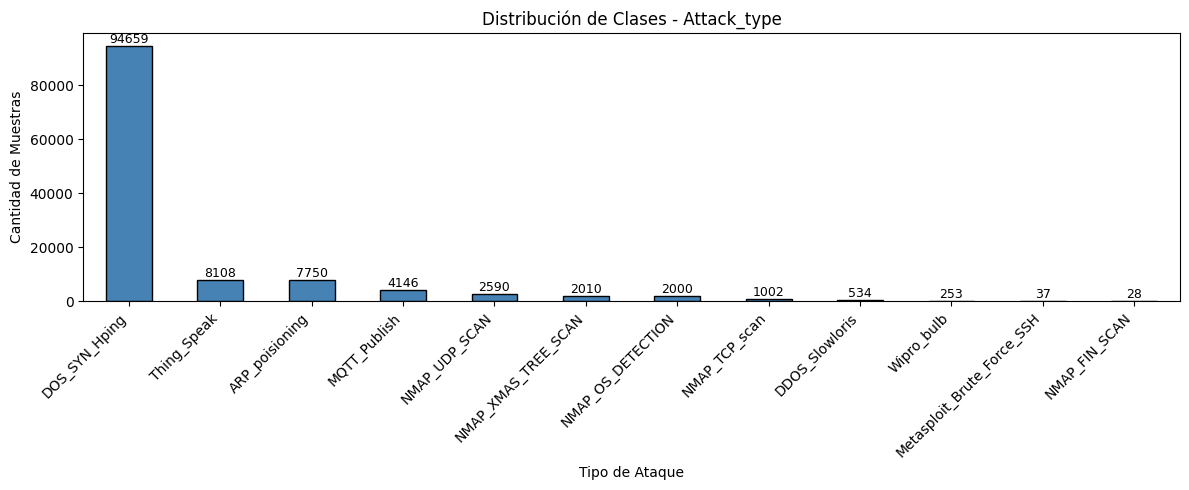

In [ ]:
plt.figure(figsize=(12, 5))
ax = data_limpio['Attack_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Distribución de Clases - Attack_type')
plt.xlabel('Tipo de Ataque')
plt.ylabel('Cantidad de Muestras')
plt.xticks(rotation=45, ha='right')

# Agregar el número encima de cada barra
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()